In [77]:
# import axelrod as axl
import matplotlib
import matplotlib.pyplot as plt
# from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import pandas as pd
import json
# import dask.dataframe as dd

import pathlib
import re

# import sympy as sym

# from itertools import combinations
# import tqdm
# from collections import defaultdict

# from matplotlib.ticker import LinearLocator

In [15]:
with open("./data/original_tournament_with_probabilistic_end/fortran_characteristics.json", "r") as f:
    characteristics = json.load(f)

In [16]:
second_tournament_strategies = [
    name for name in characteristics.keys()
    if characteristics[name]["original_rank"] is not None
]

## Helping Functions

In [65]:
def get_turns(filename):
    """
    Read the number of turns if included in the file name
    """
    match = re.search("[0-9]+(?=(_turns))", str(filename))
    return int(match.group(0))

def get_repetitions(filename):
    """
    Read the number of repetitions if included in the file name
    """
    match = re.search("[0-9]+(?=(_repetitions))", str(filename))
    return int(match.group(0))

def read_tournament_repetitions(files, player_names=None):
    """
    Read the scores from a collection of gz files 
    representing repetitions of tournaments.
    """
    number_of_opponents = len(player_names) - 1
    dfs = []
    for gz_path in files:
        dfs.append(pd.read_csv(str(gz_path), header=None).iloc[:,0:number_of_opponents + 1])
        
        turns = get_turns(gz_path)
        
        dfs[-1] /= turns * (number_of_opponents)  # Scale all metrics
        dfs[-1].columns = player_names
        
    df = pd.concat(dfs, ignore_index=True)
    return df

def read_payoff_matrix(files):
    arrays = []
    turns = []
    repetitions = 0
    for gz_path in files:
        repetitions += get_repetitions(gz_path)
        arrays.append(np.array(pd.read_csv(str(gz_path), header=None)))  # Read through pd to deal with float conversion
        turns.append(get_turns(str(gz_path)))
    payoff_matrix = sum(array * turn for turn, array in zip(turns, arrays)) / sum(turns)

    return payoff_matrix, repetitions


def get_matching_lengths_file(scores_path):
    return pathlib.Path(
        str(scores_path).replace(
            "_scores.gz",
            "_match_lengths_per_tournament.gz"
        )
    )

def read_probabilistic_tournament_repetitions(files, player_names):
    dfs = []

    number_of_opponents = len(player_names) - 1

    for scores_path in files:
        scores_path = pathlib.Path(scores_path)
        lengths_path = get_matching_lengths_file(scores_path)

        scores = pd.read_csv(scores_path, header=None)
        lengths = pd.read_csv(lengths_path, header=None)

        scores = scores.iloc[:, :len(player_names)]
        lengths = lengths.iloc[:, :len(player_names)]

        normalised_scores = scores / (lengths * number_of_opponents)

        normalised_scores.columns = player_names

        dfs.append(normalised_scores)

    return pd.concat(dfs, ignore_index=True)


def get_matching_lengths_file(scores_path):
    return pathlib.Path(
        str(scores_path).replace(
            "_scores.gz",
            "_match_lengths_per_tournament.gz"
        )
    )


def read_probabilistic_payoff_matrix(files):
    weighted_arrays = []
    length_arrays = []

    repetitions = 0

    for scores_path in files:

        repetitions += get_repetitions(scores_path)

        scores = np.array(
            pd.read_csv(scores_path, header=None)
        )

        lengths_path = get_matching_lengths_file(scores_path)

        lengths = np.array(
            pd.read_csv(lengths_path, header=None)
        )

        weighted_arrays.append(scores * lengths)
        length_arrays.append(lengths)

    payoff_matrix = (
        np.sum(weighted_arrays, axis=0)
        / np.sum(length_arrays, axis=0)
    )

    return payoff_matrix, repetitions

## Data

In [66]:
original_tournament_data_path = pathlib.Path("./data/original_tournament/")
original_tournament_scores = read_tournament_repetitions(
                                   files=original_tournament_data_path.glob("*scores.gz"), 
                                   player_names=second_tournament_strategies)

In [67]:
original_tournament_payoff_matrix, original_repetitions = read_payoff_matrix(original_tournament_data_path.glob("*payoff_matrix.gz"))

In [68]:
scores = pd.DataFrame(original_tournament_payoff_matrix, 
                      second_tournament_strategies)
scores.columns = scores.index

In [69]:
scores["Scores"] = np.mean(original_tournament_payoff_matrix, axis=1)
scores["Reproduced Rank"] = scores["Scores"].rank(ascending=False).astype(int)
scores["Original Rank"] =  [characteristics[name]["original_rank"] for name in scores.index]
scores["Author"] =  [characteristics[name]["author"] for name in scores.index]
scores.sort_values("Original Rank", inplace=True)

In [70]:
probend_tournament_data_path = pathlib.Path("./data/original_tournament_with_probabilistic_end/")
probend_tournament_scores = read_probabilistic_tournament_repetitions(
                                   files=probend_tournament_data_path.glob("*scores.gz"), 
                                   player_names=second_tournament_strategies)

In [71]:
probend_tournament_payoff_matrix, _ = read_probabilistic_payoff_matrix(probend_tournament_data_path.glob("*payoff_matrix.gz"))

In [100]:
probend = pd.DataFrame(probend_tournament_payoff_matrix, 
                       second_tournament_strategies)
probend.columns = probend.index

probend["Scores"] = np.mean(probend_tournament_payoff_matrix, axis=1)
probend["Reproduced Rank"] = probend["Scores"].rank(ascending=False).astype(int)
probend["Original Rank"] =  [characteristics[name]["original_rank"] for name in probend.index]
probend.sort_values("Original Rank", inplace=True)

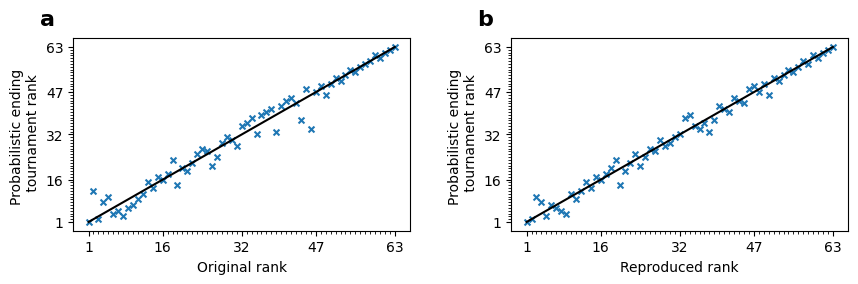

In [125]:
fig, axes = plt.subplot_mosaic("""AB""", figsize=(10, 2.5),
                               gridspec_kw={"hspace": 0.4, "wspace": 0.3,
                                            "height_ratios": [1]});

xtick_positions = range(1, len(scores.index) + 1)
labels = [f"{i}" for i in [1, 16, 32, 47, 63]]
labels[0] = "1\n" + r"$(\mathit{k92r})$"
labels[-1] = "63\n" + r"$(\mathit{k36r})$"


for letter in "AB":
    axes[letter].set_xticks([1, 16, 32, 47, 63])
    axes[letter].set_xticks(range(1, len(scores.index) + 1), minor=True)
    axes[letter].set_yticks([1, 16, 32, 47, 63])
    axes[letter].set_yticks(range(1, len(scores.index) + 1), minor=True)


for letter in "AB":
    axes[letter].plot(scores["Original Rank"], scores["Original Rank"], color="black")
               
axes["A"].scatter(
    scores["Original Rank"], probend["Reproduced Rank"], 
    label="Reproduced Rank", s=18, marker='x', color='tab:blue'
)

axes["A"].set_ylabel("Probabilistic ending \n tournament rank")
axes["A"].set_xlabel("Original rank")

axes["B"].scatter(
    scores["Reproduced Rank"], probend["Reproduced Rank"], 
    label="Reproduced Rank", s=18, marker='x', color='tab:blue'
)

axes["B"].set_ylabel("Probabilistic ending \n tournament rank")
axes["B"].set_xlabel("Reproduced rank")

panel_labels = dict(zip("AB", "ab"))
for key, label in panel_labels.items():
    axes[key].text(-0.1, 1.15, f"{label}", transform=axes[key].transAxes,
                   fontsize=16, fontweight='bold', va='top', ha='left');